In [8]:
import gym
from gym import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---------------------------------------------------------
# 0. Device Setup
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------
# 1. Custom City Environment (Multi-Agent)
# ---------------------------------------------------------

class CityTaxiEnv(gym.Env):
    """
    A 4x5 Grid City Environment for Taxi Service (100 Cars).

    Layout:
    Row 0: [0, 1, 2, 3, 4]  <-- High Demand Zone
    Row 1: [5, 6, 7, 8, 9]
    Row 2: [10, 11, 12, 13, 14]
    Row 3: [15, 16, 17, 18, 19]

    Rewards:
    - Node 4 (Top-Right): 100.0 (10x)
    - Nodes 0-3 (Rest of Row 0): 50.0 (5x)
    - Nodes 5-19 (Others): 10.0 (1x)
    """

    def __init__(self, num_taxis=100):
        super(CityTaxiEnv, self).__init__()

        self.rows = 4
        self.cols = 5
        self.num_nodes = self.rows * self.cols
        self.num_taxis = num_taxis

        # Action space: 0=Pickup, 1-4=Move
        self.action_space = spaces.Discrete(5)

        # Observation: My Position (1) + Demand Map (20)
        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(1 + self.num_nodes,),
            dtype=np.float32
        )

        self.max_steps = 72 # 24 hours / 20 min steps
        self.current_step = 0
        self.taxi_locs = np.zeros(self.num_taxis, dtype=int)
        self.demand = np.zeros(self.num_nodes)

    def _get_coords(self, node):
        return node // self.cols, node % self.cols

    def _get_node(self, r, c):
        return r * self.cols + c

    def _generate_demand(self):
        """Generates Poisson demand for the step."""
        demand = np.zeros(self.num_nodes)

        # --- MODIFIED DEMAND ZONES ---
        # Highest Row (Nodes 0-4): High Demand
        for i in range(5):
            demand[i] = np.random.poisson(lam=0.8)

        # All other rows (Nodes 5-19): Low Demand
        for i in range(5, 20):
            demand[i] = np.random.poisson(lam=0.2)
        # -----------------------------
        return demand

    def _get_observation_batch(self):
        locs = self.taxi_locs.reshape(-1, 1)
        demands = np.tile(self.demand, (self.num_taxis, 1))
        return np.concatenate((locs, demands), axis=1).astype(np.float32)

    def reset(self):
        self.current_step = 0
        self.taxi_locs = np.random.randint(0, self.num_nodes, size=self.num_taxis)
        self.demand = self._generate_demand()
        return self._get_observation_batch()

    def step(self, actions):
        rewards = np.zeros(self.num_taxis)
        done = False
        picked_up_map = np.zeros(self.num_nodes)

        for i in range(self.num_taxis):
            action = actions[i]
            loc = self.taxi_locs[i]
            r, c = self._get_coords(loc)

            if action == 0: # PICK UP
                if self.demand[loc] > 0:

                    # --- MODIFIED REWARD STRUCTURE ---
                    if loc == 4:
                        # Top-Right Node (Super Bonus)
                        rewards[i] = 100.0
                    elif loc < 5:
                        # Rest of Highest Row (Nodes 0,1,2,3)
                        rewards[i] = 50.0
                    else:
                        # Standard Zone
                        rewards[i] = 10.0
                    # ---------------------------------

                    self.demand[loc] -= 1
                    picked_up_map[loc] += 1
                    self.taxi_locs[i] = np.random.randint(0, self.num_nodes)
                else:
                    rewards[i] = -1.0

            else: # MOVE
                new_r, new_c = r, c
                if action == 1: new_r -= 1
                elif action == 2: new_r += 1
                elif action == 3: new_c -= 1
                elif action == 4: new_c += 1

                if 0 <= new_r < self.rows and 0 <= new_c < self.cols:
                    self.taxi_locs[i] = self._get_node(new_r, new_c)
                else:
                    rewards[i] = -0.5

        new_demand = self._generate_demand()
        self.demand += new_demand
        self.demand = np.clip(self.demand, 0, 50)

        self.current_step += 1
        if self.current_step >= self.max_steps:
            done = True

        next_obs = self._get_observation_batch()
        info = {'generated_demand': new_demand, 'picked_up_map': picked_up_map}
        return next_obs, rewards, done, info

# ---------------------------------------------------------
# 2. PPO Classes
# ---------------------------------------------------------

class Policy(object):
    def __init__(self, obssize, actsize, lr, device):
        self.device = device
        self.actsize = actsize
        self.model = torch.nn.Sequential(
            torch.nn.Linear(obssize, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, actsize)
        ).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def compute_prob(self, states):
        states = torch.FloatTensor(states).to(self.device)
        logits = self.model(states)
        prob = torch.nn.functional.softmax(logits, dim=-1)
        return prob.cpu().data.numpy()

    def train(self, states, actions, Qs):
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        Qs = torch.FloatTensor(Qs).to(self.device)

        logits = self.model(states)
        prob = torch.nn.functional.softmax(logits, dim=-1)
        prob_selected = prob.gather(1, actions.unsqueeze(1)).squeeze(1) + 1e-8
        log_prob_selected = torch.log(prob_selected)
        loss = -torch.mean(Qs * log_prob_selected)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.detach().cpu().data.numpy()

class ValueFunction(object):
    def __init__(self, obssize, lr, device):
        self.device = device
        self.model = torch.nn.Sequential(
            torch.nn.Linear(obssize, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1)
        ).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def compute_values(self, states):
        states = torch.FloatTensor(states).to(self.device)
        return self.model(states).cpu().data.numpy()

    def train(self, states, targets):
        states = torch.FloatTensor(states).to(self.device)
        targets = torch.FloatTensor(targets).to(self.device)
        v_preds = self.model(states)
        loss = torch.nn.functional.mse_loss(v_preds, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.detach().cpu().data.numpy()

def discounted_rewards(r, gamma):
    discounted_r = np.zeros_like(r, dtype=np.float32)
    running_sum = 0
    for i in reversed(range(0, len(r))):
        discounted_r[i] = running_sum * gamma + r[i]
        running_sum = discounted_r[i]
    return list(discounted_r)

# ---------------------------------------------------------
# 3. Training & Visualization
# ---------------------------------------------------------

def evaluate(policy, env, episodes):
    total_score = 0
    for episode in range(episodes):
        obs_batch = env.reset()
        done = False
        episode_reward = 0
        while not done:
            p = policy.compute_prob(obs_batch)
            actions = []
            for i in range(env.num_taxis):
                p_i = p[i] / np.sum(p[i])
                act = np.random.choice(np.arange(env.action_space.n), p=p_i)
                actions.append(act)
            obs_batch, rewards, done, _ = env.step(actions)
            episode_reward += np.sum(rewards)
        total_score += episode_reward
    return total_score / episodes

def run_baseline(env, episodes=50):
    print(f"\nRunning Baseline...")
    total_score = 0
    for episode in range(episodes):
        obs_batch = env.reset()
        done = False
        episode_reward = 0
        while not done:
            actions = []
            current_demand_snapshot = env.demand.copy()
            for i in range(env.num_taxis):
                loc = env.taxi_locs[i]
                if current_demand_snapshot[loc] > 0:
                    action = 0 # Pickup
                    current_demand_snapshot[loc] -= 1
                else:
                    action = np.random.randint(1, 5)
                actions.append(action)
            obs_batch, rewards, done, _ = env.step(actions)
            episode_reward += np.sum(rewards)
        total_score += episode_reward
    return total_score / episodes


def _run_logged_episode(policy, env, log_taxis=3):
    """Run one episode while capturing stats, actions, and sample taxi paths."""
    obs_batch = env.reset()
    done = False

    taxi_visits = np.zeros(env.num_nodes)
    demand_generated = np.zeros(env.num_nodes)
    demand_matched = np.zeros(env.num_nodes)
    cumulative_profit = []
    current_profit = 0.0

    action_history = []
    reward_history = []
    demand_history = []
    per_taxi_actions = []
    tracked_indices = list(range(min(log_taxis, env.num_taxis)))
    taxi_paths = {idx: [env.taxi_locs[idx]] for idx in tracked_indices}
    tracked_actions = {idx: [] for idx in tracked_indices}

    while not done:
        for loc in env.taxi_locs:
            taxi_visits[loc] += 1

        demand_history.append(env.demand.copy())
        p = policy.compute_prob(obs_batch)
        actions = []
        for i in range(env.num_taxis):
            p_i = p[i] / np.sum(p[i])
            act = np.random.choice(np.arange(env.action_space.n), p=p_i)
            actions.append(act)

        per_taxi_actions.append(actions)
        action_history.append(np.bincount(actions, minlength=env.action_space.n))
        obs_batch, rewards, done, info = env.step(actions)

        reward_step = np.sum(rewards)
        reward_history.append(reward_step)

        current_profit += reward_step
        cumulative_profit.append(current_profit)
        demand_generated += info['generated_demand']
        demand_matched += info['picked_up_map']

        for idx in tracked_indices:
            taxi_paths[idx].append(env.taxi_locs[idx])
            tracked_actions[idx].append(actions[idx])

    return {
        'taxi_visits': taxi_visits,
        'demand_generated': demand_generated,
        'demand_matched': demand_matched,
        'cumulative_profit': cumulative_profit,
        'action_history': np.array(action_history),
        'reward_history': np.array(reward_history),
        'taxi_paths': taxi_paths,
        'demand_history': np.array(demand_history),
        'per_taxi_actions': np.array(per_taxi_actions),
        'tracked_actions': tracked_actions
    }

def visualize_last_day(policy, env, log_taxis=3, return_logs=False):
    """Visualize fleet stats plus per-step action usage for the last episode."""
    print("\nVisualizing last day (1 Episode)...")
    logs = _run_logged_episode(policy, env, log_taxis=log_taxis)

    taxi_visits = logs['taxi_visits']
    demand_generated = logs['demand_generated']
    demand_matched = logs['demand_matched']
    cumulative_profit = logs['cumulative_profit']
    action_history = logs['action_history']
    taxi_paths = logs['taxi_paths']
    demand_history = logs['demand_history']
    per_taxi_actions = logs['per_taxi_actions']
    tracked_actions = logs['tracked_actions']

    # --- VISUALIZATION LOGIC ---
    fig = plt.figure(figsize=(10, 22))
    gs = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 0.6, 0.8])

    def plot_grid_graph(ax, data, title, cmap='Blues'):
        """Plots a graph representation with nodes and edges."""
        rows, cols = env.rows, env.cols

        # Color mapping
        norm = plt.Normalize(vmin=data.min(), vmax=data.max())
        m = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

        # 1. Draw Edges (Grid structure)
        for r in range(rows):
            for c in range(cols):
                # Horizontal
                if c < cols - 1:
                    ax.plot([c, c+1], [-r, -r], color='#CCCCCC', linewidth=2, zorder=1)
                # Vertical
                if r < rows - 1:
                    ax.plot([c, c], [-r, -r-1], color='#CCCCCC', linewidth=2, zorder=1)

        # 2. Draw Nodes (Circles)
        for r in range(rows):
            for c in range(cols):
                val = data[r, c]
                color = m.to_rgba(val)
                circle = patches.Circle((c, -r), 0.35, color=color, zorder=2)
                ax.add_patch(circle)

                # Contrast check for text
                brightness = (0.299*color[0] + 0.587*color[1] + 0.114*color[2])
                text_color = 'white' if brightness < 0.5 else 'black'

                ax.text(c, -r, f"{int(val)}",
                        ha='center', va='center',
                        color=text_color, fontweight='bold', fontsize=10, zorder=3)

        ax.set_title(title, fontsize=14, pad=20)
        ax.set_xlim(-0.5, cols-0.5)
        ax.set_ylim(-rows+0.5, 0.5)
        ax.axis('off')
        ax.set_aspect(1.5)

    # Reshape data
    visit_grid = taxi_visits.reshape(env.rows, env.cols)
    gen_grid = demand_generated.reshape(env.rows, env.cols)
    match_grid = demand_matched.reshape(env.rows, env.cols)

    # Plot Graphs
    ax1 = fig.add_subplot(gs[0])
    plot_grid_graph(ax1, visit_grid, "Taxi Presence (Total Visits)", cmap='Purples')

    ax2 = fig.add_subplot(gs[1])
    plot_grid_graph(ax2, gen_grid, "Total Demand Generated (High only in Top Row)", cmap='Reds')

    ax3 = fig.add_subplot(gs[2])
    plot_grid_graph(ax3, match_grid, "Total Demand Matched (Pickups)", cmap='Greens')

    # Plot Profit Curve
    ax4 = fig.add_subplot(gs[3])
    ax4.plot(cumulative_profit, color='blue', linewidth=2)
    ax4.set_title("Cumulative Profit", fontsize=12)
    ax4.set_xlabel("Time Step (20 mins)")
    ax4.set_ylabel("Profit ($)")
    ax4.grid(True, alpha=0.3)

    # Plot action usage over time
    ax5 = fig.add_subplot(gs[4])
    if action_history.size > 0:
        steps = np.arange(1, action_history.shape[0] + 1)
        action_labels = ['Pickup', 'Up', 'Down', 'Left', 'Right']
        for action_id in range(env.action_space.n):
            label = action_labels[action_id] if action_id < len(action_labels) else f"Action {action_id}"
            ax5.plot(steps, action_history[:, action_id], label=label)
        ax5.set_xlim(1, len(steps))
        ax5.legend(loc='upper right')
    else:
        ax5.text(0.5, 0.5, "No action history logged", ha='center', va='center', fontsize=12)
    ax5.set_title("Action Usage Per Step", fontsize=12)
    ax5.set_xlabel("Time Step (20 mins)")
    ax5.set_ylabel("# of Taxis")
    ax5.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Plot tracked taxi paths in a separate figure for clarity
    if taxi_paths:
        fig_paths, ax_paths = plt.subplots(figsize=(6, 6))
        for r in range(env.rows + 1):
            ax_paths.plot([-0.5, env.cols - 0.5], [-r, -r], color='#DDDDDD', linewidth=1)
        for c in range(env.cols + 1):
            ax_paths.plot([c - 0.5, c - 0.5], [0.5, -env.rows + 0.5], color='#DDDDDD', linewidth=1)

        traj_cmap = plt.cm.get_cmap('plasma')
        cmap_norm = plt.Normalize(0, 1)
        sm = plt.cm.ScalarMappable(cmap=traj_cmap, norm=cmap_norm)
        handles = []

        for idx, path in taxi_paths.items():
            coords = [env._get_coords(node) for node in path]
            xs = np.array([c for r, c in coords], dtype=float)
            ys = np.array([-r for r, c in coords], dtype=float)
            if len(xs) < 2:
                continue
            points = np.column_stack((xs, ys)).reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            progress = np.linspace(0, 1, len(segments))
            lc = LineCollection(segments, cmap=traj_cmap, norm=cmap_norm, linewidth=2)
            lc.set_array(progress)
            ax_paths.add_collection(lc)

            start_color = traj_cmap(0.0)
            end_color = traj_cmap(1.0)
            ax_paths.scatter(xs[0], ys[0], marker='o', color=start_color, edgecolors='black', s=40)
            handle = ax_paths.scatter(xs[-1], ys[-1], marker='^', color=end_color, edgecolors='black', s=50, label=f"Taxi {idx}")
            handles.append(handle)

        if handles:
            ax_paths.legend(handles=handles, loc='best', title="Taxi Destinations")
        cbar = fig_paths.colorbar(sm, ax=ax_paths, fraction=0.046, pad=0.04)
        cbar.set_label("Path Progression")

        ax_paths.set_title("Tracked Taxi Trajectories", fontsize=12)
        ax_paths.set_xlim(-0.5, env.cols - 0.5)
        ax_paths.set_ylim(-env.rows + 0.5, 0.5)
        ax_paths.set_xlabel("Column")
        ax_paths.set_ylabel("Row")
        ax_paths.set_aspect('equal')
        fig_paths.tight_layout()

        if return_logs:
            return logs

        # Day timeline visualizations (demand per node + tracked action sequences)
        if demand_history.size > 0 and per_taxi_actions.size > 0:
            fig_day, (ax_demand, ax_moves) = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

            im = ax_demand.imshow(demand_history, aspect='auto', cmap='Reds')
            ax_demand.set_title("Demand Heatmap Over Day (Step x Node)")
            ax_demand.set_xlabel("Node ID")
            ax_demand.set_ylabel("Time Step")
            fig_day.colorbar(im, ax=ax_demand, label="Pending Requests")

            if tracked_actions:
                tracked_ids = sorted(tracked_actions.keys())
                action_matrix = np.array([tracked_actions[idx] for idx in tracked_ids])
                if action_matrix.size > 0:
                    action_cmap = ListedColormap(['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#8c564b'])
                    bounds = np.arange(-0.5, env.action_space.n + 0.5, 1)
                    norm = BoundaryNorm(bounds, action_cmap.N)
                    moves = ax_moves.imshow(action_matrix, aspect='auto', cmap=action_cmap, norm=norm, interpolation='nearest')
                    ax_moves.set_title("Tracked Taxi Actions Over Day")
                    ax_moves.set_xlabel("Time Step")
                    ax_moves.set_ylabel("Taxi Index")
                    ax_moves.set_yticks(np.arange(len(tracked_ids)))
                    ax_moves.set_yticklabels(tracked_ids)
                    cbar_moves = fig_day.colorbar(moves, ax=ax_moves, ticks=range(env.action_space.n))
                    cbar_moves.ax.set_yticklabels(['Pickup', 'Up', 'Down', 'Left', 'Right'])
        plt.show()

Using device: cpu



Running Baseline...

Starting PPO Training...
Iteration 0, Avg Fleet Reward: 1284.30
Iteration 10, Avg Fleet Reward: 7950.20
Iteration 20, Avg Fleet Reward: 9100.90
Iteration 30, Avg Fleet Reward: 10305.10
Iteration 40, Avg Fleet Reward: 8958.70
Iteration 50, Avg Fleet Reward: 9261.70
Iteration 60, Avg Fleet Reward: 10027.60
Iteration 70, Avg Fleet Reward: 10681.00
Iteration 80, Avg Fleet Reward: 9350.60
Iteration 90, Avg Fleet Reward: 11207.40
Iteration 100, Avg Fleet Reward: 10423.30
Iteration 110, Avg Fleet Reward: 9228.00
Iteration 120, Avg Fleet Reward: 11012.40
Iteration 130, Avg Fleet Reward: 10613.00
Iteration 140, Avg Fleet Reward: 11241.30
Iteration 150, Avg Fleet Reward: 11017.20
Iteration 160, Avg Fleet Reward: 11387.90
Iteration 170, Avg Fleet Reward: 10926.60
Iteration 180, Avg Fleet Reward: 11001.00
Iteration 190, Avg Fleet Reward: 10998.40
Iteration 200, Avg Fleet Reward: 11119.50
Iteration 210, Avg Fleet Reward: 11522.50
Iteration 220, Avg Fleet Reward: 10644.00
Itera

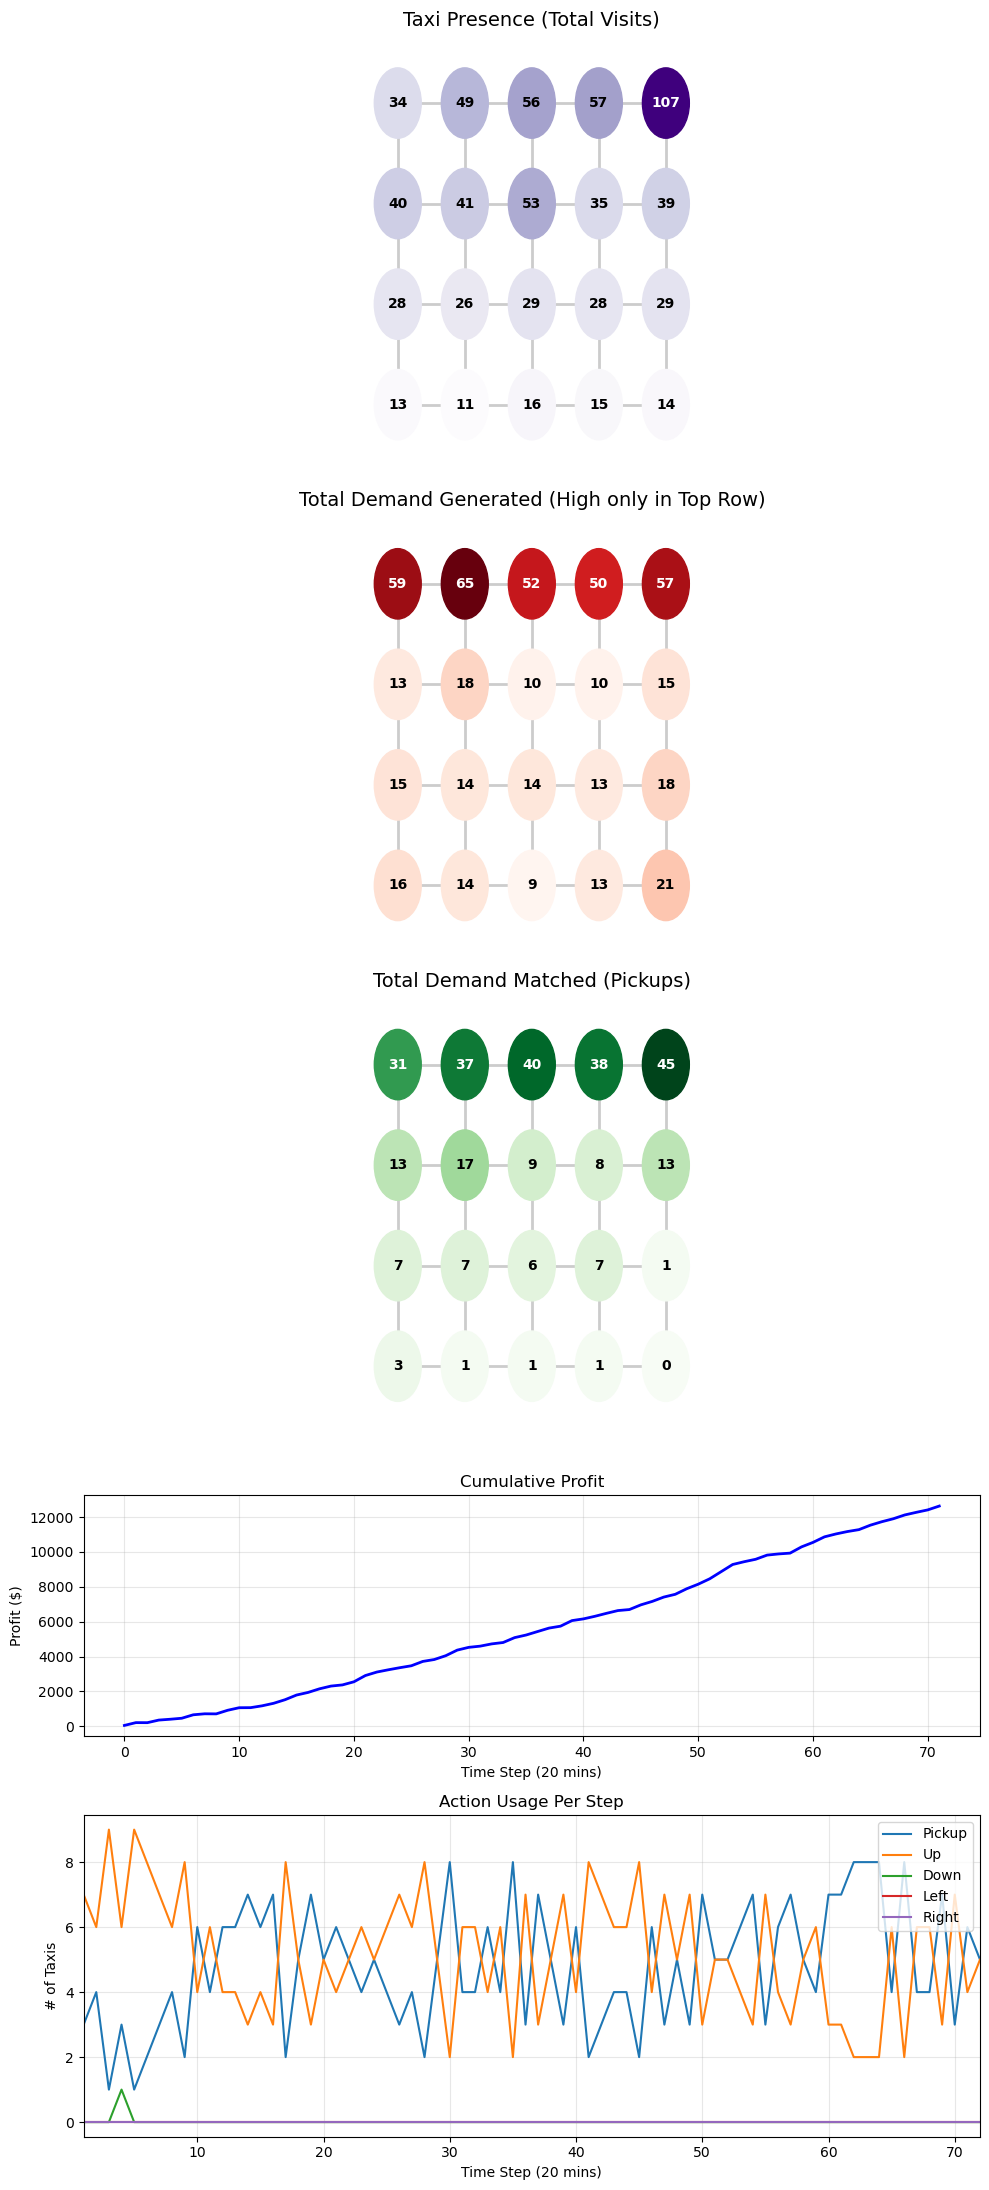

/var/folders/z0/5ztwx44s2fx664kw1gfggz_m0000gn/T/ipykernel_98782/2696682041.py:439: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  traj_cmap = plt.cm.get_cmap('plasma')


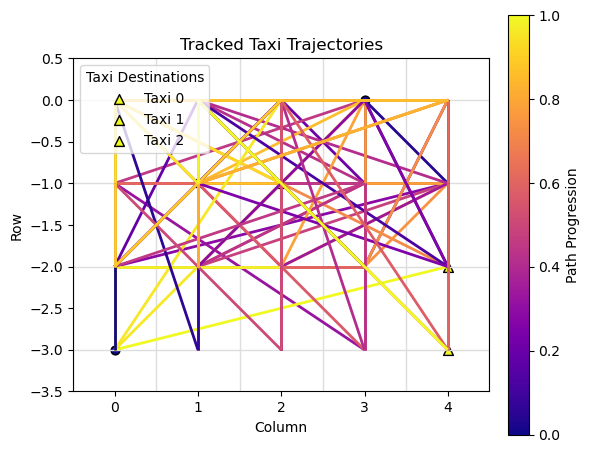

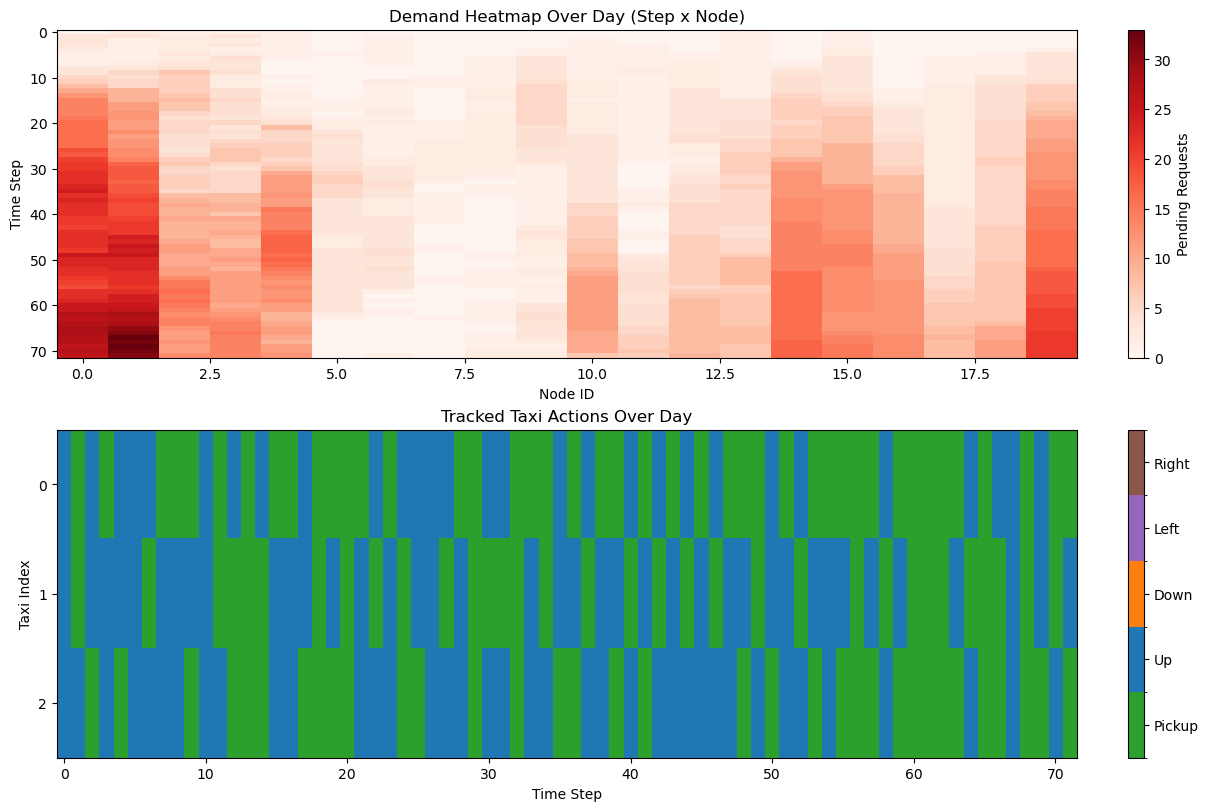

In [9]:
alpha = 1e-3
beta = 1e-3
numtrajs = 5
iterations = 500
gamma = 0.997
num_taxis = 10

env = CityTaxiEnv(num_taxis=num_taxis)
obssize = env.observation_space.shape[0]
actsize = env.action_space.n

# --- CALCULATE BASELINE ---
baseline_score = run_baseline(env, episodes=50)

actor = Policy(obssize, actsize, alpha, device)
baseline = ValueFunction(obssize, beta, device)

print("\nStarting PPO Training...")

for ite in range(iterations):
    OBS_BUFFER = []
    ACTS_BUFFER = []
    VAL_BUFFER = []
    total_batch_reward = 0

    for num in range(numtrajs):
        car_obss = [[] for _ in range(num_taxis)]
        car_acts = [[] for _ in range(num_taxis)]
        car_rews = [[] for _ in range(num_taxis)]
        obs_batch = env.reset()
        done = False

        while not done:
            for i in range(num_taxis):
                car_obss[i].append(obs_batch[i])
            probs = actor.compute_prob(obs_batch)
            actions = []
            for i in range(num_taxis):
                a = np.random.choice(actsize, p=probs[i].flatten())
                actions.append(a)
                car_acts[i].append(a)
            next_obs_batch, rewards, done, _ = env.step(actions)
            for i in range(num_taxis):
                car_rews[i].append(rewards[i])
            obs_batch = next_obs_batch

        ep_total = 0
        for i in range(num_taxis):
            ep_total += np.sum(car_rews[i])
            dis_r = discounted_rewards(car_rews[i], gamma)
            OBS_BUFFER.extend(car_obss[i])
            ACTS_BUFFER.extend(car_acts[i])
            VAL_BUFFER.extend(dis_r)
        total_batch_reward += ep_total

    if ite % 10 == 0:
        print(f"Iteration {ite}, Avg Fleet Reward: {total_batch_reward / numtrajs:.2f}")

    obs_train = np.array(OBS_BUFFER)
    val_train = np.array(VAL_BUFFER)
    acts_train = np.array(ACTS_BUFFER)

    baseline.train(obs_train, val_train)
    v_preds = baseline.compute_values(obs_train).flatten()
    advantages = val_train - v_preds
    if advantages.std() > 1e-8:
        advantages = (advantages - advantages.mean()) / advantages.std()
    actor.train(obs_train, acts_train, advantages)

# --- EVALUATE AND COMPARE ---
print("\nTraining Complete. Evaluating PPO...")
test_score = evaluate(actor, env, episodes=50)

print("-" * 30)
print(f"Baseline Score:       {baseline_score:.2f}")
print(f"Final PPO Test Score: {test_score:.2f}")
print("-" * 30)

if test_score > baseline_score:
    print("Result: PPO outperformed the Baseline!")
else:
    print("Result: PPO failed to beat the Baseline.")

visualize_last_day(actor, env)

Using device: cpu

Running Baseline...

Starting PPO Training...
Iteration 0, Avg Fleet Reward: 125.70
Iteration 10, Avg Fleet Reward: 4555.50
Iteration 20, Avg Fleet Reward: 7882.80
Iteration 30, Avg Fleet Reward: 9850.60
Iteration 40, Avg Fleet Reward: 8858.80
Iteration 50, Avg Fleet Reward: 9832.60
Iteration 60, Avg Fleet Reward: 10224.70
Iteration 70, Avg Fleet Reward: 10966.70
Iteration 80, Avg Fleet Reward: 10199.00
Iteration 90, Avg Fleet Reward: 10624.30
Iteration 100, Avg Fleet Reward: 11179.00
Iteration 110, Avg Fleet Reward: 10862.40
Iteration 120, Avg Fleet Reward: 10611.20
Iteration 130, Avg Fleet Reward: 10025.10
Iteration 140, Avg Fleet Reward: 11292.50
Iteration 150, Avg Fleet Reward: 11432.40
Iteration 160, Avg Fleet Reward: 10979.00
Iteration 170, Avg Fleet Reward: 11964.40
Iteration 180, Avg Fleet Reward: 11223.70
Iteration 190, Avg Fleet Reward: 11489.40
Iteration 200, Avg Fleet Reward: 11586.20
Iteration 210, Avg Fleet Reward: 11590.80
Iteration 220, Avg Fleet Rewa

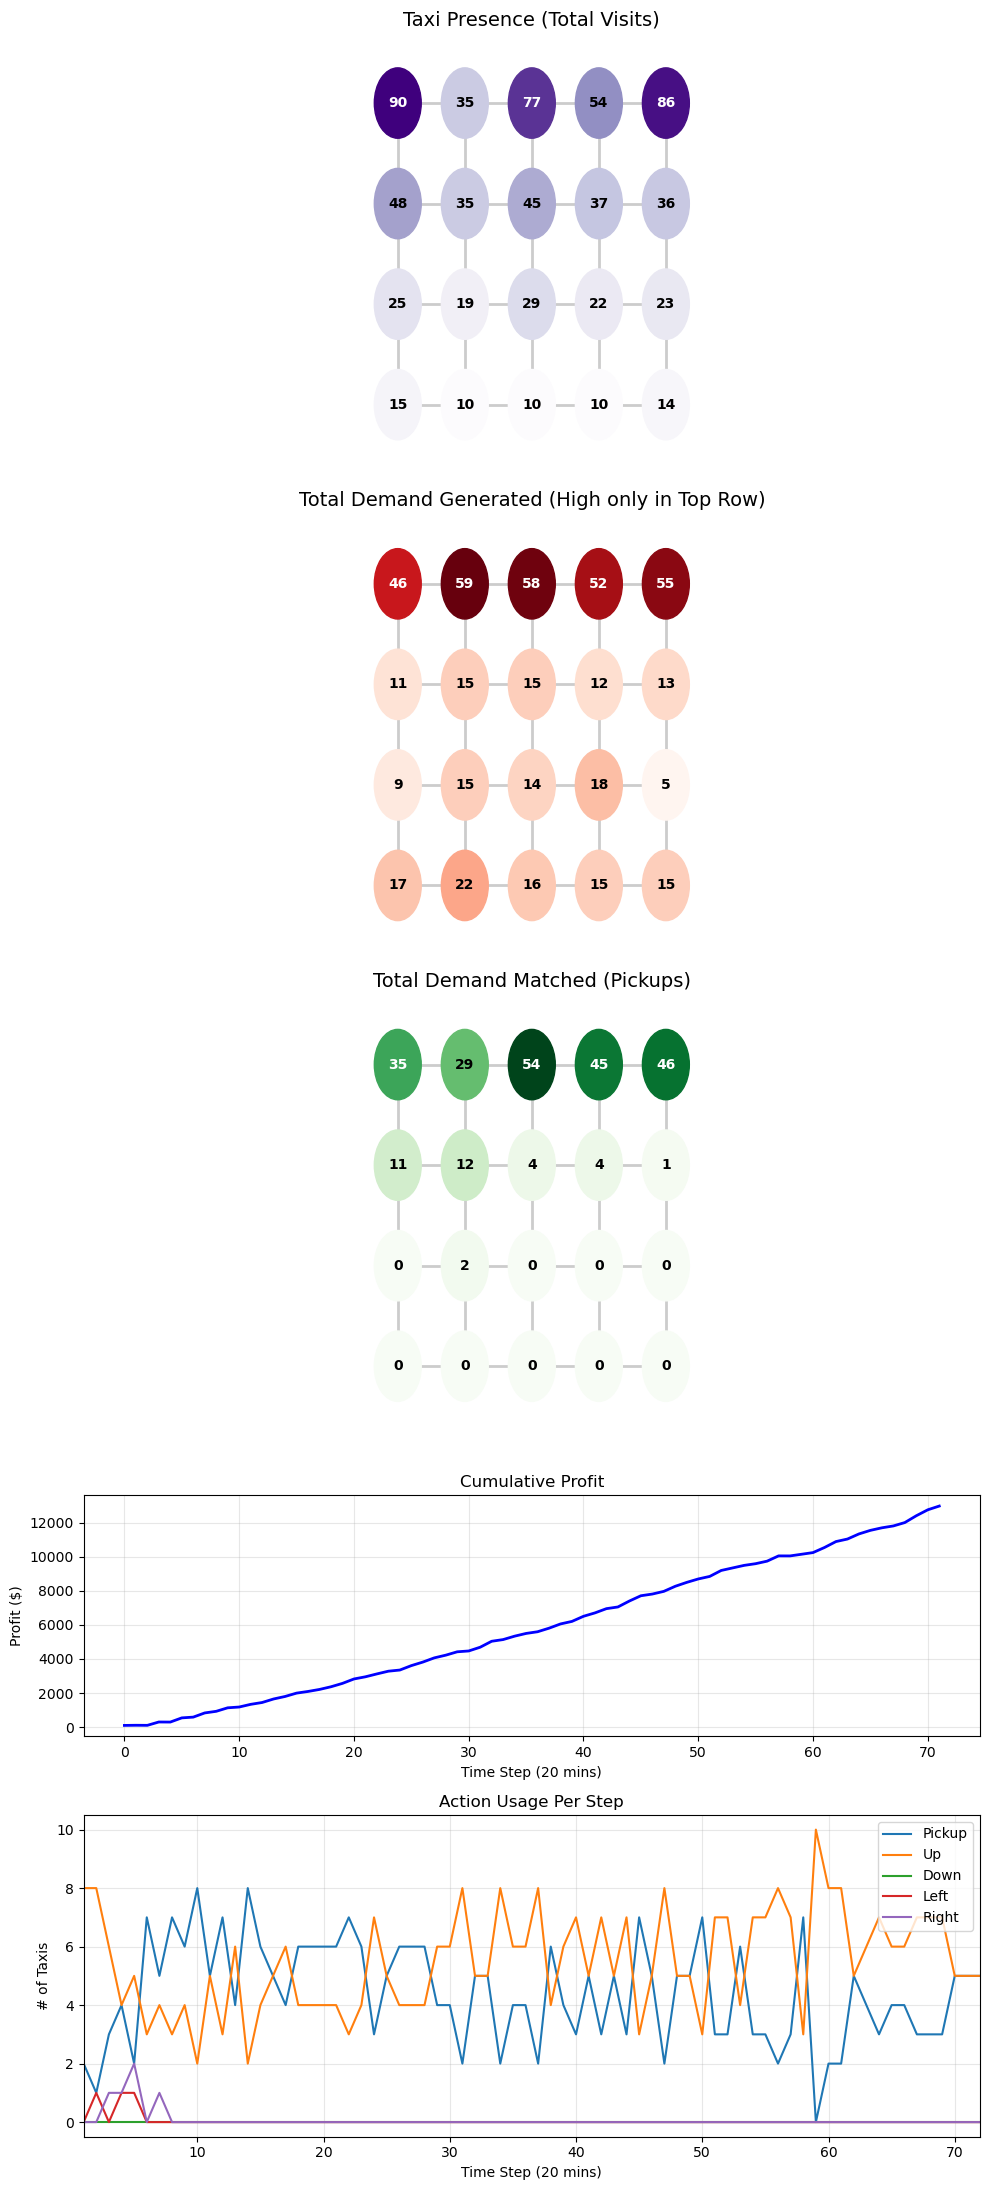

/var/folders/z0/5ztwx44s2fx664kw1gfggz_m0000gn/T/ipykernel_98782/2538830726.py:481: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  traj_cmap = plt.cm.get_cmap('plasma')


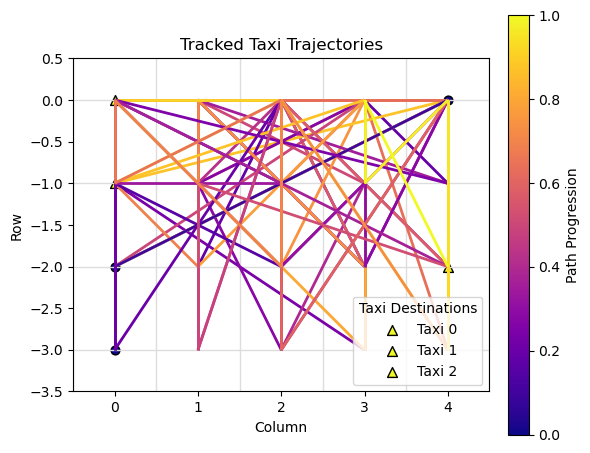

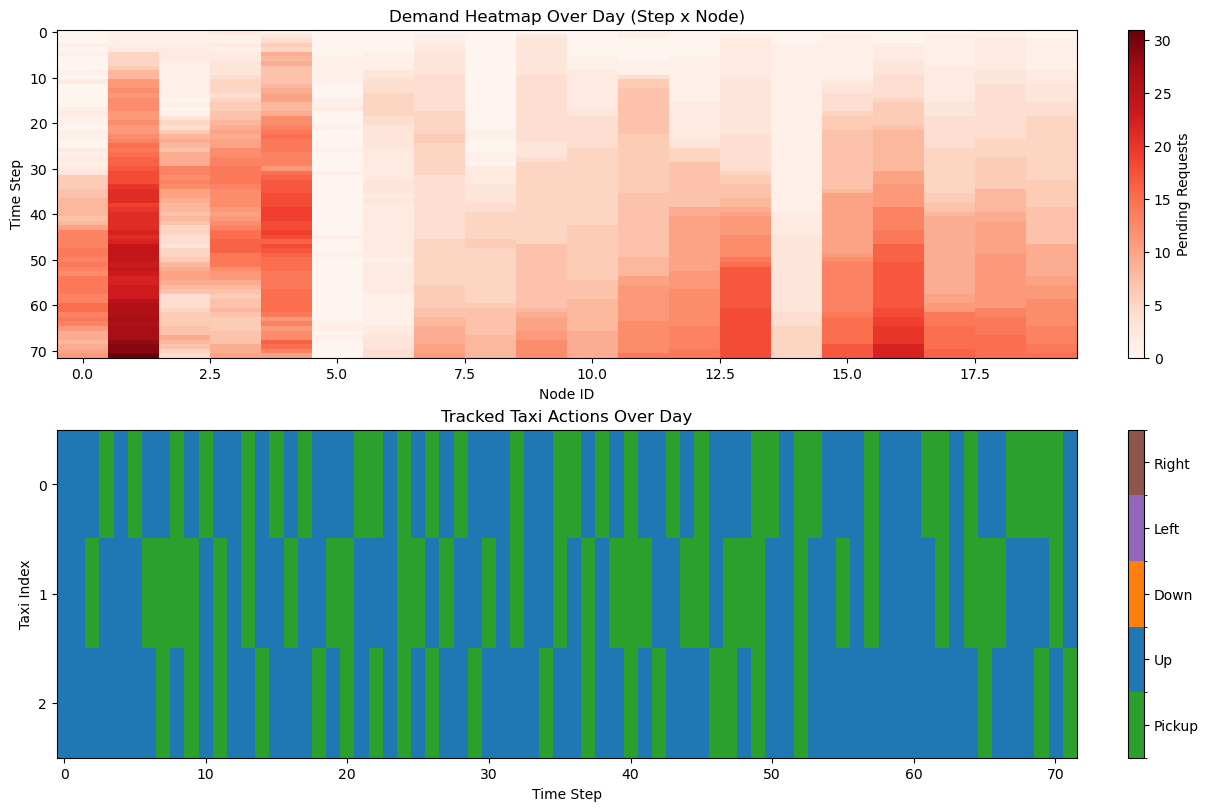

In [10]:
import gym
from gym import spaces
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, BoundaryNorm

# ---------------------------------------------------------
# 0. Device Setup
# ---------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# ---------------------------------------------------------
# 1. Custom City Environment (Multi-Agent)
# ---------------------------------------------------------

class CityTaxiEnv(gym.Env):
    """
    A 4x5 Grid City Environment for Taxi Service (100 Cars).

    Layout:
    Row 0: [0, 1, 2, 3, 4]  <-- High Demand Zone
    Row 1: [5, 6, 7, 8, 9]
    Row 2: [10, 11, 12, 13, 14]
    Row 3: [15, 16, 17, 18, 19]

    Rewards:
    - Node 4 (Top-Right): 100.0 (10x)
    - Nodes 0-3 (Rest of Row 0): 50.0 (5x)
    - Nodes 5-19 (Others): 10.0 (1x)
    """

    def __init__(self, num_taxis=100):
        super(CityTaxiEnv, self).__init__()

        self.rows = 4
        self.cols = 5
        self.num_nodes = self.rows * self.cols
        self.num_taxis = num_taxis

        # Action space: 0=Pickup, 1-4=Move
        self.action_space = spaces.Discrete(5)

        # Observation: My Position (1) + Demand Map (20)
        self.observation_space = spaces.Box(
            low=0,
            high=100,
            shape=(1 + self.num_nodes,),
            dtype=np.float32
        )

        self.max_steps = 72 # 24 hours / 20 min steps
        self.current_step = 0
        self.taxi_locs = np.zeros(self.num_taxis, dtype=int)
        self.demand = np.zeros(self.num_nodes)

    def _get_coords(self, node):
        return node // self.cols, node % self.cols

    def _get_node(self, r, c):
        return r * self.cols + c

    def _generate_demand(self):
        """Generates Poisson demand for the step."""
        demand = np.zeros(self.num_nodes)

        # --- MODIFIED DEMAND ZONES ---
        # Highest Row (Nodes 0-4): High Demand
        for i in range(5):
            demand[i] = np.random.poisson(lam=0.8)

        # All other rows (Nodes 5-19): Low Demand
        for i in range(5, 20):
            demand[i] = np.random.poisson(lam=0.2)
        # -----------------------------
        return demand

    def _get_observation_batch(self):
        locs = self.taxi_locs.reshape(-1, 1)
        demands = np.tile(self.demand, (self.num_taxis, 1))
        return np.concatenate((locs, demands), axis=1).astype(np.float32)

    def reset(self):
        self.current_step = 0
        self.taxi_locs = np.random.randint(0, self.num_nodes, size=self.num_taxis)
        self.demand = self._generate_demand()
        return self._get_observation_batch()

    def step(self, actions):
        rewards = np.zeros(self.num_taxis)
        done = False
        picked_up_map = np.zeros(self.num_nodes)

        for i in range(self.num_taxis):
            action = actions[i]
            loc = self.taxi_locs[i]
            r, c = self._get_coords(loc)

            if action == 0: # PICK UP
                if self.demand[loc] > 0:

                    # --- MODIFIED REWARD STRUCTURE ---
                    if loc == 4:
                        # Top-Right Node (Super Bonus)
                        rewards[i] = 100.0
                    elif loc < 5:
                        # Rest of Highest Row (Nodes 0,1,2,3)
                        rewards[i] = 50.0
                    else:
                        # Standard Zone
                        rewards[i] = 10.0
                    # ---------------------------------

                    self.demand[loc] -= 1
                    picked_up_map[loc] += 1
                    self.taxi_locs[i] = np.random.randint(0, self.num_nodes)
                else:
                    rewards[i] = -1.0

            else: # MOVE
                new_r, new_c = r, c
                if action == 1: new_r -= 1
                elif action == 2: new_r += 1
                elif action == 3: new_c -= 1
                elif action == 4: new_c += 1

                if 0 <= new_r < self.rows and 0 <= new_c < self.cols:
                    self.taxi_locs[i] = self._get_node(new_r, new_c)
                else:
                    rewards[i] = -0.5

        new_demand = self._generate_demand()
        self.demand += new_demand
        self.demand = np.clip(self.demand, 0, 50)

        self.current_step += 1
        if self.current_step >= self.max_steps:
            done = True

        next_obs = self._get_observation_batch()
        info = {'generated_demand': new_demand, 'picked_up_map': picked_up_map}
        return next_obs, rewards, done, info

# ---------------------------------------------------------
# 2. PPO Classes
# ---------------------------------------------------------

class Policy(object):
    def __init__(self, obssize, actsize, lr, device):
        self.device = device
        self.actsize = actsize
        self.model = torch.nn.Sequential(
            torch.nn.Linear(obssize, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, actsize)
        ).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def compute_prob(self, states):
        states = torch.FloatTensor(states).to(self.device)
        logits = self.model(states)
        prob = torch.nn.functional.softmax(logits, dim=-1)
        return prob.cpu().data.numpy()

    def train(self, states, actions, Qs):
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).to(self.device)
        Qs = torch.FloatTensor(Qs).to(self.device)

        logits = self.model(states)
        prob = torch.nn.functional.softmax(logits, dim=-1)
        prob_selected = prob.gather(1, actions.unsqueeze(1)).squeeze(1) + 1e-8
        log_prob_selected = torch.log(prob_selected)
        loss = -torch.mean(Qs * log_prob_selected)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.detach().cpu().data.numpy()

class ValueFunction(object):
    def __init__(self, obssize, lr, device):
        self.device = device
        self.model = torch.nn.Sequential(
            torch.nn.Linear(obssize, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 64),
            torch.nn.ReLU(),
            torch.nn.Linear(64, 1)
        ).to(self.device)
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)

    def compute_values(self, states):
        states = torch.FloatTensor(states).to(self.device)
        return self.model(states).cpu().data.numpy()

    def train(self, states, targets):
        states = torch.FloatTensor(states).to(self.device)
        targets = torch.FloatTensor(targets).to(self.device)
        v_preds = self.model(states)
        loss = torch.nn.functional.mse_loss(v_preds, targets.unsqueeze(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        return loss.detach().cpu().data.numpy()

def discounted_rewards(r, gamma):
    discounted_r = np.zeros_like(r, dtype=np.float32)
    running_sum = 0
    for i in reversed(range(0, len(r))):
        discounted_r[i] = running_sum * gamma + r[i]
        running_sum = discounted_r[i]
    return list(discounted_r)

# ---------------------------------------------------------
# 3. Training & Visualization
# ---------------------------------------------------------

def evaluate(policy, env, episodes):
    total_score = 0
    for episode in range(episodes):
        obs_batch = env.reset()
        done = False
        episode_reward = 0
        while not done:
            p = policy.compute_prob(obs_batch)
            actions = []
            for i in range(env.num_taxis):
                p_i = p[i] / np.sum(p[i])
                act = np.random.choice(np.arange(env.action_space.n), p=p_i)
                actions.append(act)
            obs_batch, rewards, done, _ = env.step(actions)
            episode_reward += np.sum(rewards)
        total_score += episode_reward
    return total_score / episodes

def run_baseline(env, episodes=50):
    print(f"\nRunning Baseline...")
    total_score = 0
    for episode in range(episodes):
        obs_batch = env.reset()
        done = False
        episode_reward = 0
        while not done:
            actions = [0] * env.num_taxis
            demand_nodes = np.where(env.demand > 0)[0]
            taxi_coords = [env._get_coords(loc) for loc in env.taxi_locs]
            assigned = set()
            taxi_targets = {}

            # Assign nearest idle taxi to each demand node
            for node in demand_nodes:
                node_r, node_c = env._get_coords(node)
                best_idx = None
                best_dist = float('inf')
                for idx, (taxi_r, taxi_c) in enumerate(taxi_coords):
                    if idx in assigned:
                        continue
                    dist = abs(node_r - taxi_r) + abs(node_c - taxi_c)
                    if dist < best_dist:
                        best_dist = dist
                        best_idx = idx
                if best_idx is not None:
                    taxi_targets[best_idx] = node
                    assigned.add(best_idx)

            # Choose actions based on assignments
            for idx in range(env.num_taxis):
                loc = env.taxi_locs[idx]
                cur_r, cur_c = taxi_coords[idx]

                if env.demand[loc] > 0:
                    actions[idx] = 0  # immediate pickup
                    continue

                target_node = taxi_targets.get(idx)
                if target_node is None:
                    # Gravitate toward the highest-demand node (default to top row)
                    if env.demand.sum() > 0:
                        target_node = int(np.argmax(env.demand))
                    else:
                        target_node = 2  # center of top row for lack of signal
                target_r, target_c = env._get_coords(target_node)

                if target_r < cur_r:
                    actions[idx] = 1
                elif target_r > cur_r:
                    actions[idx] = 2
                elif target_c < cur_c:
                    actions[idx] = 3
                elif target_c > cur_c:
                    actions[idx] = 4
                else:
                    # Already at target but no demand, wander horizontally
                    actions[idx] = np.random.choice([3, 4])

            obs_batch, rewards, done, _ = env.step(actions)
            episode_reward += np.sum(rewards)
        total_score += episode_reward
    return total_score / episodes


def _run_logged_episode(policy, env, log_taxis=3):
    """Run one episode while capturing stats, actions, and sample taxi paths."""
    obs_batch = env.reset()
    done = False

    taxi_visits = np.zeros(env.num_nodes)
    demand_generated = np.zeros(env.num_nodes)
    demand_matched = np.zeros(env.num_nodes)
    cumulative_profit = []
    current_profit = 0.0

    action_history = []
    reward_history = []
    demand_history = []
    per_taxi_actions = []
    tracked_indices = list(range(min(log_taxis, env.num_taxis)))
    taxi_paths = {idx: [env.taxi_locs[idx]] for idx in tracked_indices}
    tracked_actions = {idx: [] for idx in tracked_indices}

    while not done:
        for loc in env.taxi_locs:
            taxi_visits[loc] += 1

        demand_history.append(env.demand.copy())
        p = policy.compute_prob(obs_batch)
        actions = []
        for i in range(env.num_taxis):
            p_i = p[i] / np.sum(p[i])
            act = np.random.choice(np.arange(env.action_space.n), p=p_i)
            actions.append(act)

        per_taxi_actions.append(actions)
        action_history.append(np.bincount(actions, minlength=env.action_space.n))
        obs_batch, rewards, done, info = env.step(actions)

        reward_step = np.sum(rewards)
        reward_history.append(reward_step)

        current_profit += reward_step
        cumulative_profit.append(current_profit)
        demand_generated += info['generated_demand']
        demand_matched += info['picked_up_map']

        for idx in tracked_indices:
            taxi_paths[idx].append(env.taxi_locs[idx])
            tracked_actions[idx].append(actions[idx])

    return {
        'taxi_visits': taxi_visits,
        'demand_generated': demand_generated,
        'demand_matched': demand_matched,
        'cumulative_profit': cumulative_profit,
        'action_history': np.array(action_history),
        'reward_history': np.array(reward_history),
        'taxi_paths': taxi_paths,
        'demand_history': np.array(demand_history),
        'per_taxi_actions': np.array(per_taxi_actions),
        'tracked_actions': tracked_actions
    }

def visualize_last_day(policy, env, log_taxis=3, return_logs=False):
    """Visualize fleet stats plus per-step action usage for the last episode."""
    print("\nVisualizing last day (1 Episode)...")
    logs = _run_logged_episode(policy, env, log_taxis=log_taxis)

    taxi_visits = logs['taxi_visits']
    demand_generated = logs['demand_generated']
    demand_matched = logs['demand_matched']
    cumulative_profit = logs['cumulative_profit']
    action_history = logs['action_history']
    taxi_paths = logs['taxi_paths']
    demand_history = logs['demand_history']
    per_taxi_actions = logs['per_taxi_actions']
    tracked_actions = logs['tracked_actions']

    # --- VISUALIZATION LOGIC ---
    fig = plt.figure(figsize=(10, 22))
    gs = fig.add_gridspec(5, 1, height_ratios=[1, 1, 1, 0.6, 0.8])

    def plot_grid_graph(ax, data, title, cmap='Blues'):
        """Plots a graph representation with nodes and edges."""
        rows, cols = env.rows, env.cols

        # Color mapping
        norm = plt.Normalize(vmin=data.min(), vmax=data.max())
        m = plt.cm.ScalarMappable(norm=norm, cmap=cmap)

        # 1. Draw Edges (Grid structure)
        for r in range(rows):
            for c in range(cols):
                # Horizontal
                if c < cols - 1:
                    ax.plot([c, c+1], [-r, -r], color='#CCCCCC', linewidth=2, zorder=1)
                # Vertical
                if r < rows - 1:
                    ax.plot([c, c], [-r, -r-1], color='#CCCCCC', linewidth=2, zorder=1)

        # 2. Draw Nodes (Circles)
        for r in range(rows):
            for c in range(cols):
                val = data[r, c]
                color = m.to_rgba(val)
                circle = patches.Circle((c, -r), 0.35, color=color, zorder=2)
                ax.add_patch(circle)

                # Contrast check for text
                brightness = (0.299*color[0] + 0.587*color[1] + 0.114*color[2])
                text_color = 'white' if brightness < 0.5 else 'black'

                ax.text(c, -r, f"{int(val)}",
                        ha='center', va='center',
                        color=text_color, fontweight='bold', fontsize=10, zorder=3)

        ax.set_title(title, fontsize=14, pad=20)
        ax.set_xlim(-0.5, cols-0.5)
        ax.set_ylim(-rows+0.5, 0.5)
        ax.axis('off')
        ax.set_aspect(1.5)

    # Reshape data
    visit_grid = taxi_visits.reshape(env.rows, env.cols)
    gen_grid = demand_generated.reshape(env.rows, env.cols)
    match_grid = demand_matched.reshape(env.rows, env.cols)

    # Plot Graphs
    ax1 = fig.add_subplot(gs[0])
    plot_grid_graph(ax1, visit_grid, "Taxi Presence (Total Visits)", cmap='Purples')

    ax2 = fig.add_subplot(gs[1])
    plot_grid_graph(ax2, gen_grid, "Total Demand Generated (High only in Top Row)", cmap='Reds')

    ax3 = fig.add_subplot(gs[2])
    plot_grid_graph(ax3, match_grid, "Total Demand Matched (Pickups)", cmap='Greens')

    # Plot Profit Curve
    ax4 = fig.add_subplot(gs[3])
    ax4.plot(cumulative_profit, color='blue', linewidth=2)
    ax4.set_title("Cumulative Profit", fontsize=12)
    ax4.set_xlabel("Time Step (20 mins)")
    ax4.set_ylabel("Profit ($)")
    ax4.grid(True, alpha=0.3)

    # Plot action usage over time
    ax5 = fig.add_subplot(gs[4])
    if action_history.size > 0:
        steps = np.arange(1, action_history.shape[0] + 1)
        action_labels = ['Pickup', 'Up', 'Down', 'Left', 'Right']
        for action_id in range(env.action_space.n):
            label = action_labels[action_id] if action_id < len(action_labels) else f"Action {action_id}"
            ax5.plot(steps, action_history[:, action_id], label=label)
        ax5.set_xlim(1, len(steps))
        ax5.legend(loc='upper right')
    else:
        ax5.text(0.5, 0.5, "No action history logged", ha='center', va='center', fontsize=12)
    ax5.set_title("Action Usage Per Step", fontsize=12)
    ax5.set_xlabel("Time Step (20 mins)")
    ax5.set_ylabel("# of Taxis")
    ax5.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Plot tracked taxi paths in a separate figure for clarity
    if taxi_paths:
        fig_paths, ax_paths = plt.subplots(figsize=(6, 6))
        for r in range(env.rows + 1):
            ax_paths.plot([-0.5, env.cols - 0.5], [-r, -r], color='#DDDDDD', linewidth=1)
        for c in range(env.cols + 1):
            ax_paths.plot([c - 0.5, c - 0.5], [0.5, -env.rows + 0.5], color='#DDDDDD', linewidth=1)

        traj_cmap = plt.cm.get_cmap('plasma')
        cmap_norm = plt.Normalize(0, 1)
        sm = plt.cm.ScalarMappable(cmap=traj_cmap, norm=cmap_norm)
        handles = []

        for idx, path in taxi_paths.items():
            coords = [env._get_coords(node) for node in path]
            xs = np.array([c for r, c in coords], dtype=float)
            ys = np.array([-r for r, c in coords], dtype=float)
            if len(xs) < 2:
                continue
            points = np.column_stack((xs, ys)).reshape(-1, 1, 2)
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            progress = np.linspace(0, 1, len(segments))
            lc = LineCollection(segments, cmap=traj_cmap, norm=cmap_norm, linewidth=2)
            lc.set_array(progress)
            ax_paths.add_collection(lc)

            start_color = traj_cmap(0.0)
            end_color = traj_cmap(1.0)
            ax_paths.scatter(xs[0], ys[0], marker='o', color=start_color, edgecolors='black', s=40)
            handle = ax_paths.scatter(xs[-1], ys[-1], marker='^', color=end_color, edgecolors='black', s=50, label=f"Taxi {idx}")
            handles.append(handle)

        if handles:
            ax_paths.legend(handles=handles, loc='best', title="Taxi Destinations")
        cbar = fig_paths.colorbar(sm, ax=ax_paths, fraction=0.046, pad=0.04)
        cbar.set_label("Path Progression")

        ax_paths.set_title("Tracked Taxi Trajectories", fontsize=12)
        ax_paths.set_xlim(-0.5, env.cols - 0.5)
        ax_paths.set_ylim(-env.rows + 0.5, 0.5)
        ax_paths.set_xlabel("Column")
        ax_paths.set_ylabel("Row")
        ax_paths.set_aspect('equal')
        fig_paths.tight_layout()

        if return_logs:
            return logs

        # Day timeline visualizations (demand per node + tracked action sequences)
        if demand_history.size > 0 and per_taxi_actions.size > 0:
            fig_day, (ax_demand, ax_moves) = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)

            im = ax_demand.imshow(demand_history, aspect='auto', cmap='Reds')
            ax_demand.set_title("Demand Heatmap Over Day (Step x Node)")
            ax_demand.set_xlabel("Node ID")
            ax_demand.set_ylabel("Time Step")
            fig_day.colorbar(im, ax=ax_demand, label="Pending Requests")

            if tracked_actions:
                tracked_ids = sorted(tracked_actions.keys())
                action_matrix = np.array([tracked_actions[idx] for idx in tracked_ids])
                if action_matrix.size > 0:
                    action_cmap = ListedColormap(['#2ca02c', '#1f77b4', '#ff7f0e', '#9467bd', '#8c564b'])
                    bounds = np.arange(-0.5, env.action_space.n + 0.5, 1)
                    norm = BoundaryNorm(bounds, action_cmap.N)
                    moves = ax_moves.imshow(action_matrix, aspect='auto', cmap=action_cmap, norm=norm, interpolation='nearest')
                    ax_moves.set_title("Tracked Taxi Actions Over Day")
                    ax_moves.set_xlabel("Time Step")
                    ax_moves.set_ylabel("Taxi Index")
                    ax_moves.set_yticks(np.arange(len(tracked_ids)))
                    ax_moves.set_yticklabels(tracked_ids)
                    cbar_moves = fig_day.colorbar(moves, ax=ax_moves, ticks=range(env.action_space.n))
                    cbar_moves.ax.set_yticklabels(['Pickup', 'Up', 'Down', 'Left', 'Right'])
        plt.show()


def main():
    alpha = 1e-3
    beta = 1e-3
    numtrajs = 5
    iterations = 500
    gamma = 0.997
    num_taxis = 10

    env = CityTaxiEnv(num_taxis=num_taxis)
    obssize = env.observation_space.shape[0]
    actsize = env.action_space.n

    # --- CALCULATE BASELINE ---
    baseline_score = run_baseline(env, episodes=50)

    actor = Policy(obssize, actsize, alpha, device)
    baseline = ValueFunction(obssize, beta, device)

    print("\nStarting PPO Training...")

    for ite in range(iterations):
        OBS_BUFFER = []
        ACTS_BUFFER = []
        VAL_BUFFER = []
        total_batch_reward = 0

        for num in range(numtrajs):
            car_obss = [[] for _ in range(num_taxis)]
            car_acts = [[] for _ in range(num_taxis)]
            car_rews = [[] for _ in range(num_taxis)]
            obs_batch = env.reset()
            done = False

            while not done:
                for i in range(num_taxis):
                    car_obss[i].append(obs_batch[i])
                probs = actor.compute_prob(obs_batch)
                actions = []
                for i in range(num_taxis):
                    a = np.random.choice(actsize, p=probs[i].flatten())
                    actions.append(a)
                    car_acts[i].append(a)
                next_obs_batch, rewards, done, _ = env.step(actions)
                for i in range(num_taxis):
                    car_rews[i].append(rewards[i])
                obs_batch = next_obs_batch

            ep_total = 0
            for i in range(num_taxis):
                ep_total += np.sum(car_rews[i])
                dis_r = discounted_rewards(car_rews[i], gamma)
                OBS_BUFFER.extend(car_obss[i])
                ACTS_BUFFER.extend(car_acts[i])
                VAL_BUFFER.extend(dis_r)
            total_batch_reward += ep_total

        if ite % 10 == 0:
            print(f"Iteration {ite}, Avg Fleet Reward: {total_batch_reward / numtrajs:.2f}")

        obs_train = np.array(OBS_BUFFER)
        val_train = np.array(VAL_BUFFER)
        acts_train = np.array(ACTS_BUFFER)

        baseline.train(obs_train, val_train)
        v_preds = baseline.compute_values(obs_train).flatten()
        advantages = val_train - v_preds
        if advantages.std() > 1e-8:
            advantages = (advantages - advantages.mean()) / advantages.std()
        actor.train(obs_train, acts_train, advantages)

    # --- EVALUATE AND COMPARE ---
    print("\nTraining Complete. Evaluating PPO...")
    test_score = evaluate(actor, env, episodes=50)

    print("-" * 30)
    print(f"Baseline Score:       {baseline_score:.2f}")
    print(f"Final PPO Test Score: {test_score:.2f}")
    print("-" * 30)

    if test_score > baseline_score:
        print("Result: PPO outperformed the Baseline!")
    else:
        print("Result: PPO failed to beat the Baseline.")

    visualize_last_day(actor, env)

if __name__ == "__main__":
    main()